In [1]:
import litebird_sim as lbs
import numpy as np
from swipe_modules import SwipeRasterScanningStrategy
import matplotlib.pyplot as plt
import healpy as hp
import astropy

In [2]:
sim = lbs.Simulation(
    start_time=astropy.time.Time("2026-08-15T16:30"),
    duration_s=12*3600,
    description="SWIPE simulation",
    random_seed=12345,
)

In [3]:
sim.set_scanning_strategy(SwipeRasterScanningStrategy(),delta_time_s=1)

site_latitude_deg, site_longitude_deg and longitude_speed_deg_per_sec used


In [4]:
instr = lbs.InstrumentInfo(
    name="swipe",
    spin_boresight_angle_rad=np.deg2rad(40),
)
sim.set_instrument(instr)

det = lbs.DetectorInfo(name="foo", sampling_rate_hz=10)

In [5]:
obs, = sim.create_observations(detectors=[det])
sim.prepare_pointings()
sim.precompute_pointings()

In [6]:
nside = 256
npix = hp.nside2npix(nside)
h = np.zeros(npix)
for idet in [0]:
    pixidx = hp.ang2pix(nside, obs.pointing_matrix[idet, :, 0], obs.pointing_matrix[idet, :, 1])
    pixel_occurrences = np.bincount(pixidx)
    h[0:len(pixel_occurrences)] += pixel_occurrences

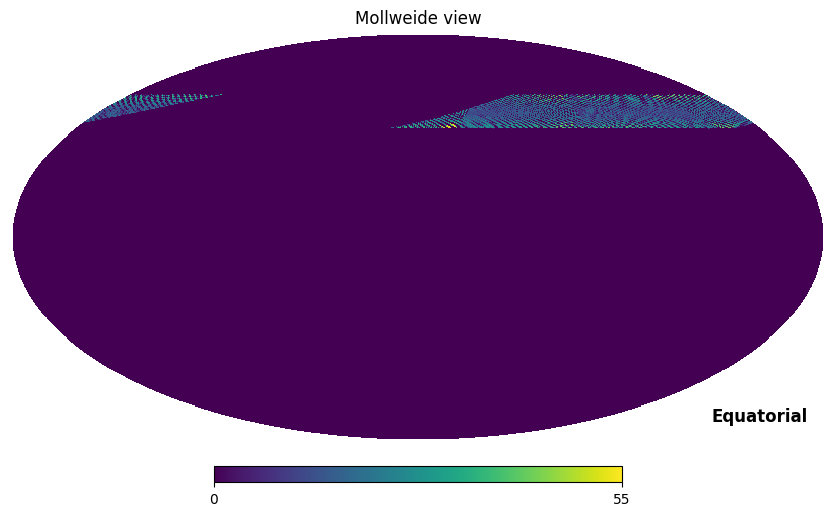

In [7]:
hp.mollview(h,coord=['E','C'])